In [ ]:
import numpy as np
import MAS_library as MASL
import Pk_library as PKL
import readfof

from astropy.table import Table, join
import os

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 360
matplotlib.rcParams['text.usetex'] = True
os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ['PATH']
plt.style.use('dark_background')

In [2]:
base = '../data/astra/fiducial_0'
# !ls ../data/astra/fiducial_0/raw

In [8]:
tab = Table.read(f'{base}/raw/zone_00_sim000_snap003.fits.gz')
len(tab)

714472

In [4]:
real_data = tab[tab['RANDITER']==-1]
len(real_data)

15532

In [5]:
pos = np.column_stack([real_data['XCART'], real_data['YCART'],real_data['ZCART']]).astype(np.float32)

pos = np.ascontiguousarray(pos)

print('shape:', pos.shape)
print('dtype:', pos.dtype)
print('min:', pos.min(axis=0))
print('max:', pos.max(axis=0))

shape: (15532, 3)
dtype: float32
min: [0.11795123 0.10009713 0.02645912]
max: [999.92    999.83496 999.89514]


In [6]:
grid = 512
MAS = 'CIC'
verbose = True

axis = 0
threads = 1
BoxSize = 1000.0

In [7]:
delta = np.zeros((grid,grid,grid), dtype=np.float32)

MASL.MA(pos, delta, BoxSize, MAS, verbose=verbose)

delta /= np.mean(delta, dtype=np.float64);  delta -= 1.0

print('%.3f < delta < %.3f'%(np.min(delta), np.max(delta)))
print('< delta > = %.3f'%np.mean(delta))


Using CIC mass assignment scheme
Time taken = 0.076 seconds

-1.000 < delta < 8540.422
< delta > = -0.000


In [8]:
# compute power spectrum
Pk = PKL.Pk(delta, BoxSize, axis, MAS, threads, verbose)

# Pk is a python class containing the 1D, 2D and 3D power spectra, that can be retrieved as

# 1D P(k)
k1D = Pk.k1D
Pk1D = Pk.Pk1D
Nmodes1D = Pk.Nmodes1D

# 2D P(k)
kpar = Pk.kpar
kper = Pk.kper
Pk2D = Pk.Pk2D
Nmodes2D = Pk.Nmodes2D

# 3D P(k)
k = Pk.k3D
Pk0 = Pk.Pk[:,0] #monopole
Pk2 = Pk.Pk[:,1] #quadrupole
Pk4 = Pk.Pk[:,2] #hexadecapole
Pkphase = Pk.Pkphase #power spectrum of the phases
Nmodes = Pk.Nmodes3D


Computing power spectrum of the field...
Time to complete loop = 4.73
Time taken = 7.88 seconds


In [11]:
Nhalos = len(pos)
volume = BoxSize**3
nbar = Nhalos / volume
Pshot = 1.0 / nbar

print('N halos:', Nhalos)
print('nbar:', nbar, '(h/Mpc)^3')
print('Pshot:', Pshot, '(Mpc/h)^3')

N halos: 15532
nbar: 1.5532e-05 (h/Mpc)^3
Pshot: 64383.20885912954 (Mpc/h)^3


In [12]:
k_nyquist = np.pi * grid / BoxSize

mask = (np.isfinite(k) & np.isfinite(Pk0) & (Nmodes > 0)
        & (k > 0) & (k <= 0.5))

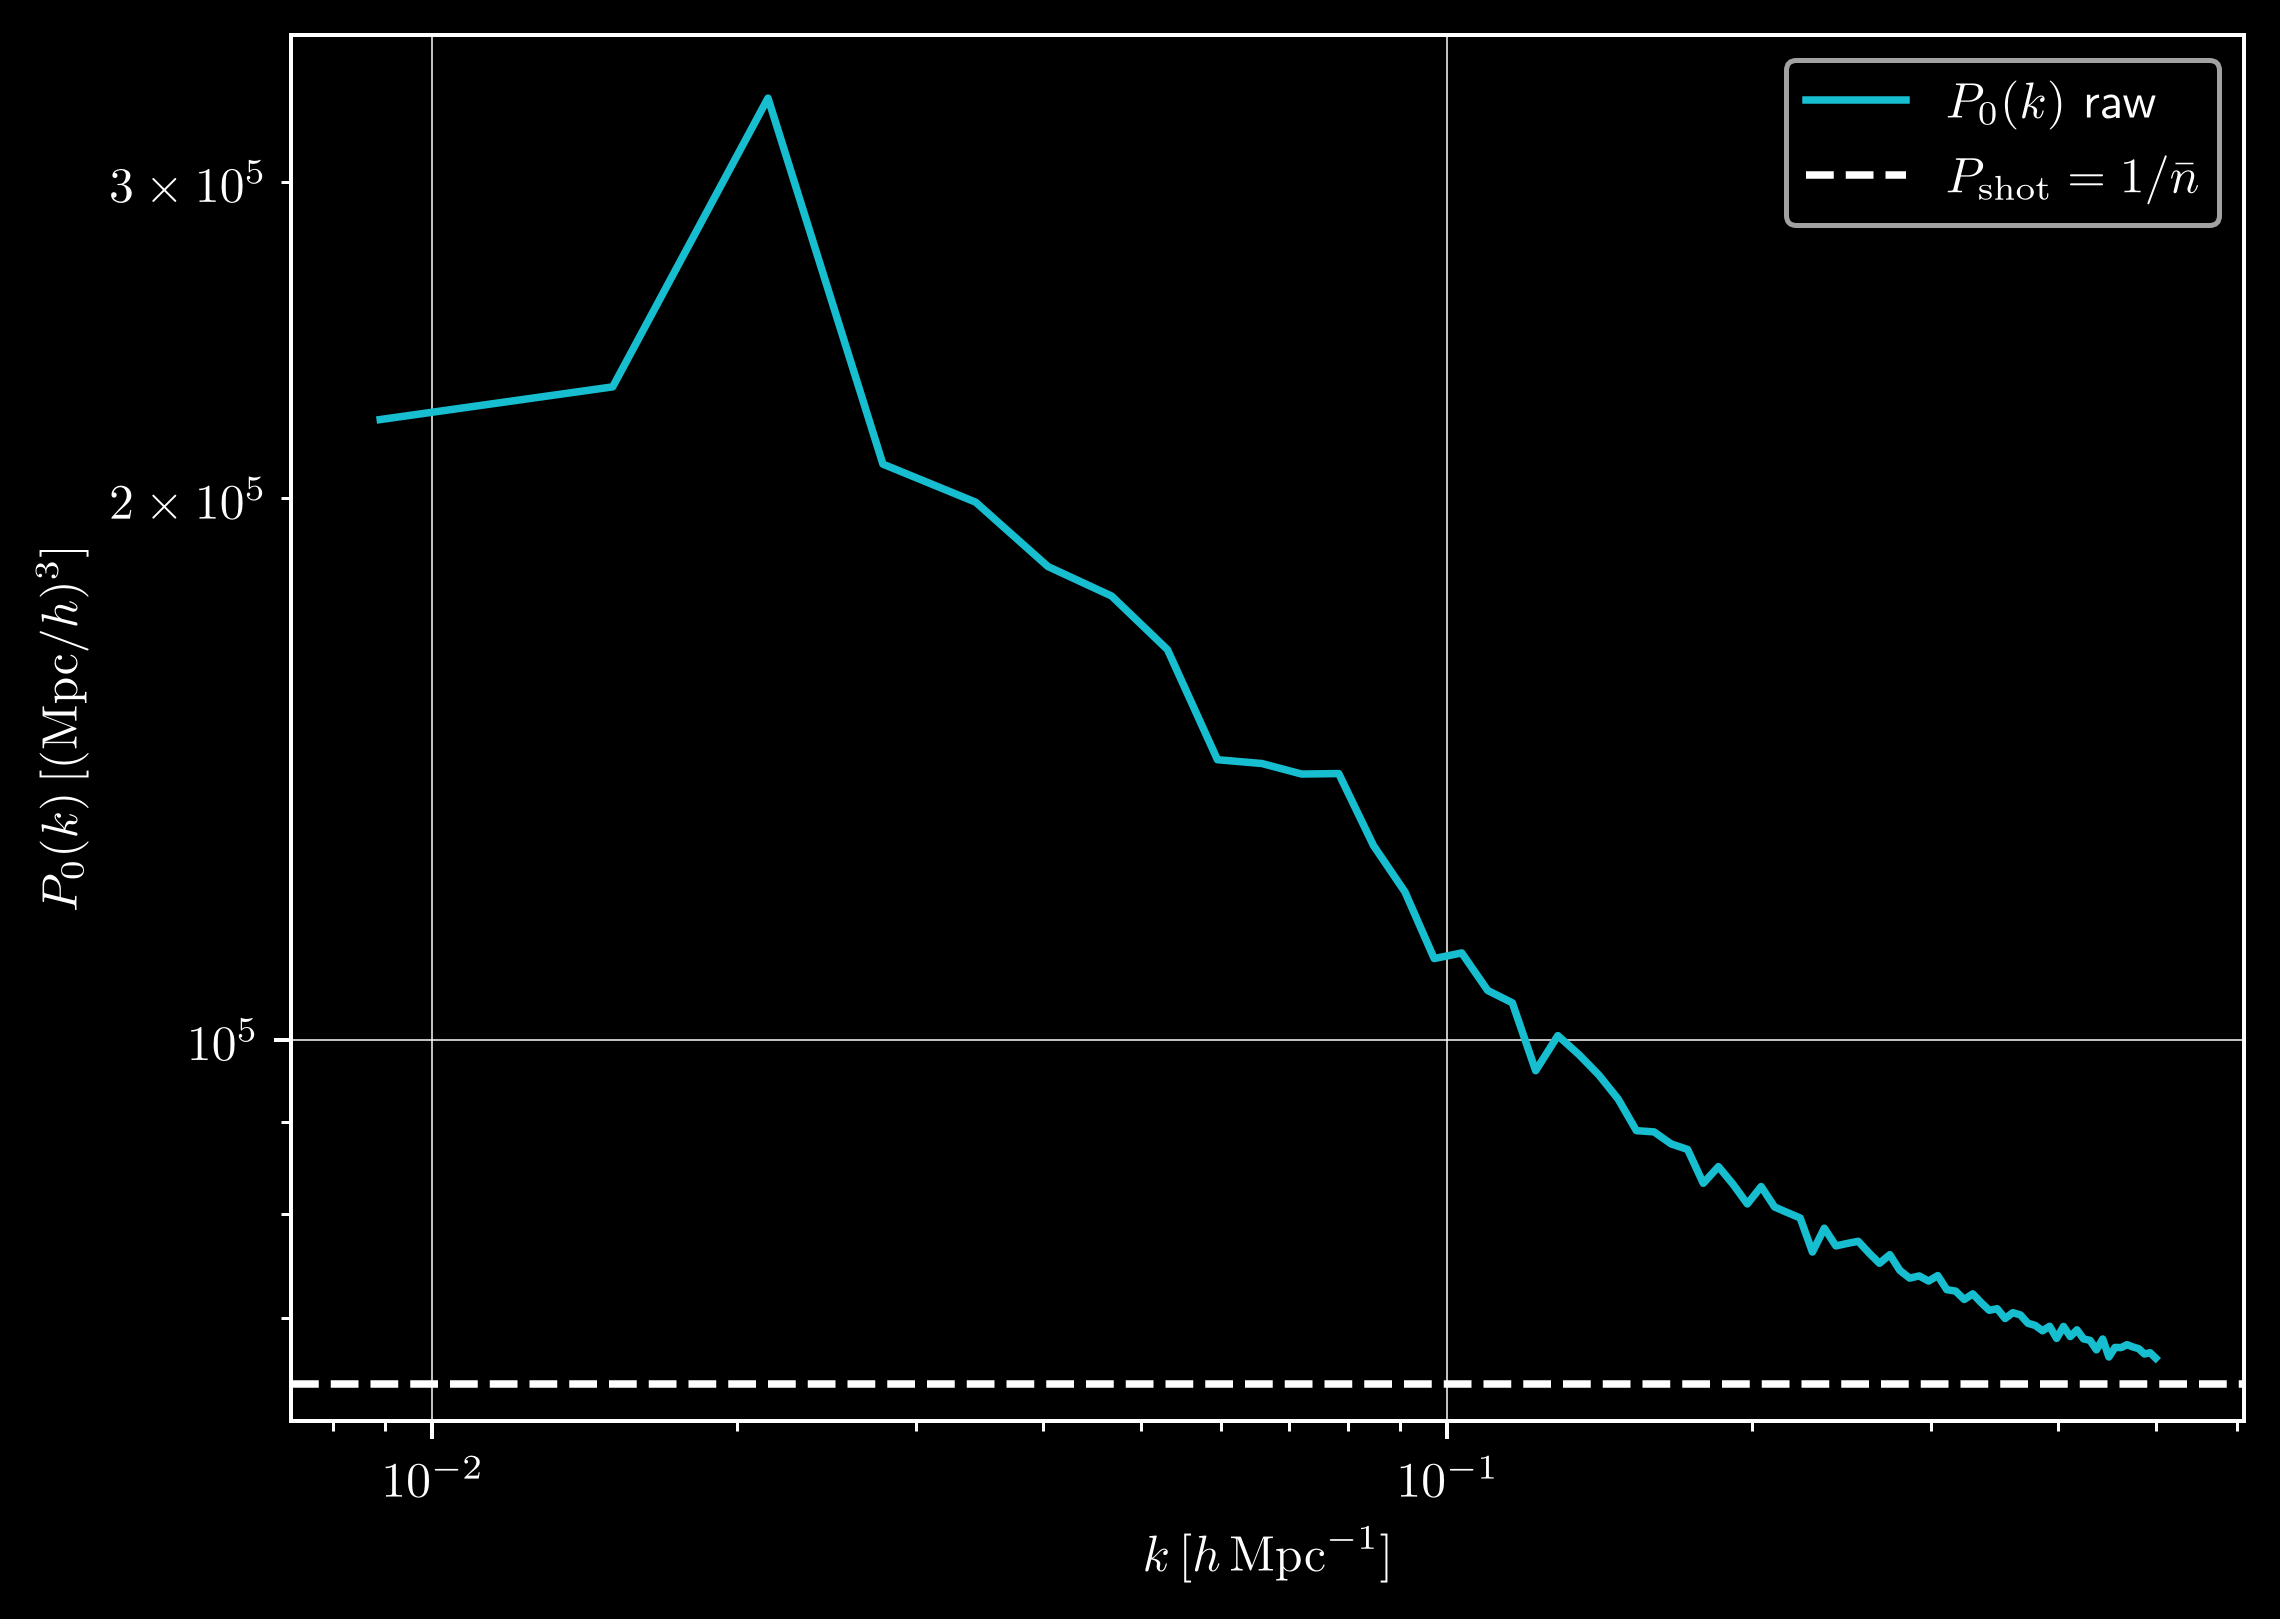

k Nyquist = 1.608 h/Mpc


In [32]:
fig, ax = plt.subplots(figsize=(7, 5))
plt.grid(lw=0.3)

ax.loglog(k[mask], Pk0[mask], label=r'$P_0(k)$ raw', c='#17becf')

ax.axhline(Pshot,linestyle='--', label=r'$P_{\rm shot}=1/\bar{n}$')

ax.set_xlabel(r'$k\,[h\,{\rm Mpc}^{-1}]$')
ax.set_ylabel(r'$P_0(k)\,[(\mathrm{Mpc}/h)^3]$')
plt.legend()

plt.show()

print(f'k Nyquist = {k_nyquist:.3f} h/Mpc')

In [14]:
for ki, pi, ni in zip(k[:10], Pk0[:10], Nmodes[:10]):
    print(f'k={ki:.5f}, P0={pi:.4e}, Nmodes={ni}')

k=0.00890, P0=2.2123e+05, Nmodes=13.0
k=0.01508, P0=2.3069e+05, Nmodes=33.0
k=0.02145, P0=3.3387e+05, Nmodes=79.0
k=0.02784, P0=2.0896e+05, Nmodes=117.0
k=0.03435, P0=1.9903e+05, Nmodes=205.0
k=0.04048, P0=1.8328e+05, Nmodes=235.0
k=0.04677, P0=1.7649e+05, Nmodes=369.0
k=0.05308, P0=1.6478e+05, Nmodes=433.0
k=0.05945, P0=1.4312e+05, Nmodes=585.0
k=0.06576, P0=1.4243e+05, Nmodes=679.0


In [15]:
Nhalos = len(pos)
volume = BoxSize**3

nbar = Nhalos / volume
Pshot = 1.0 / nbar

Pk_clustering = Pk0 - Pshot

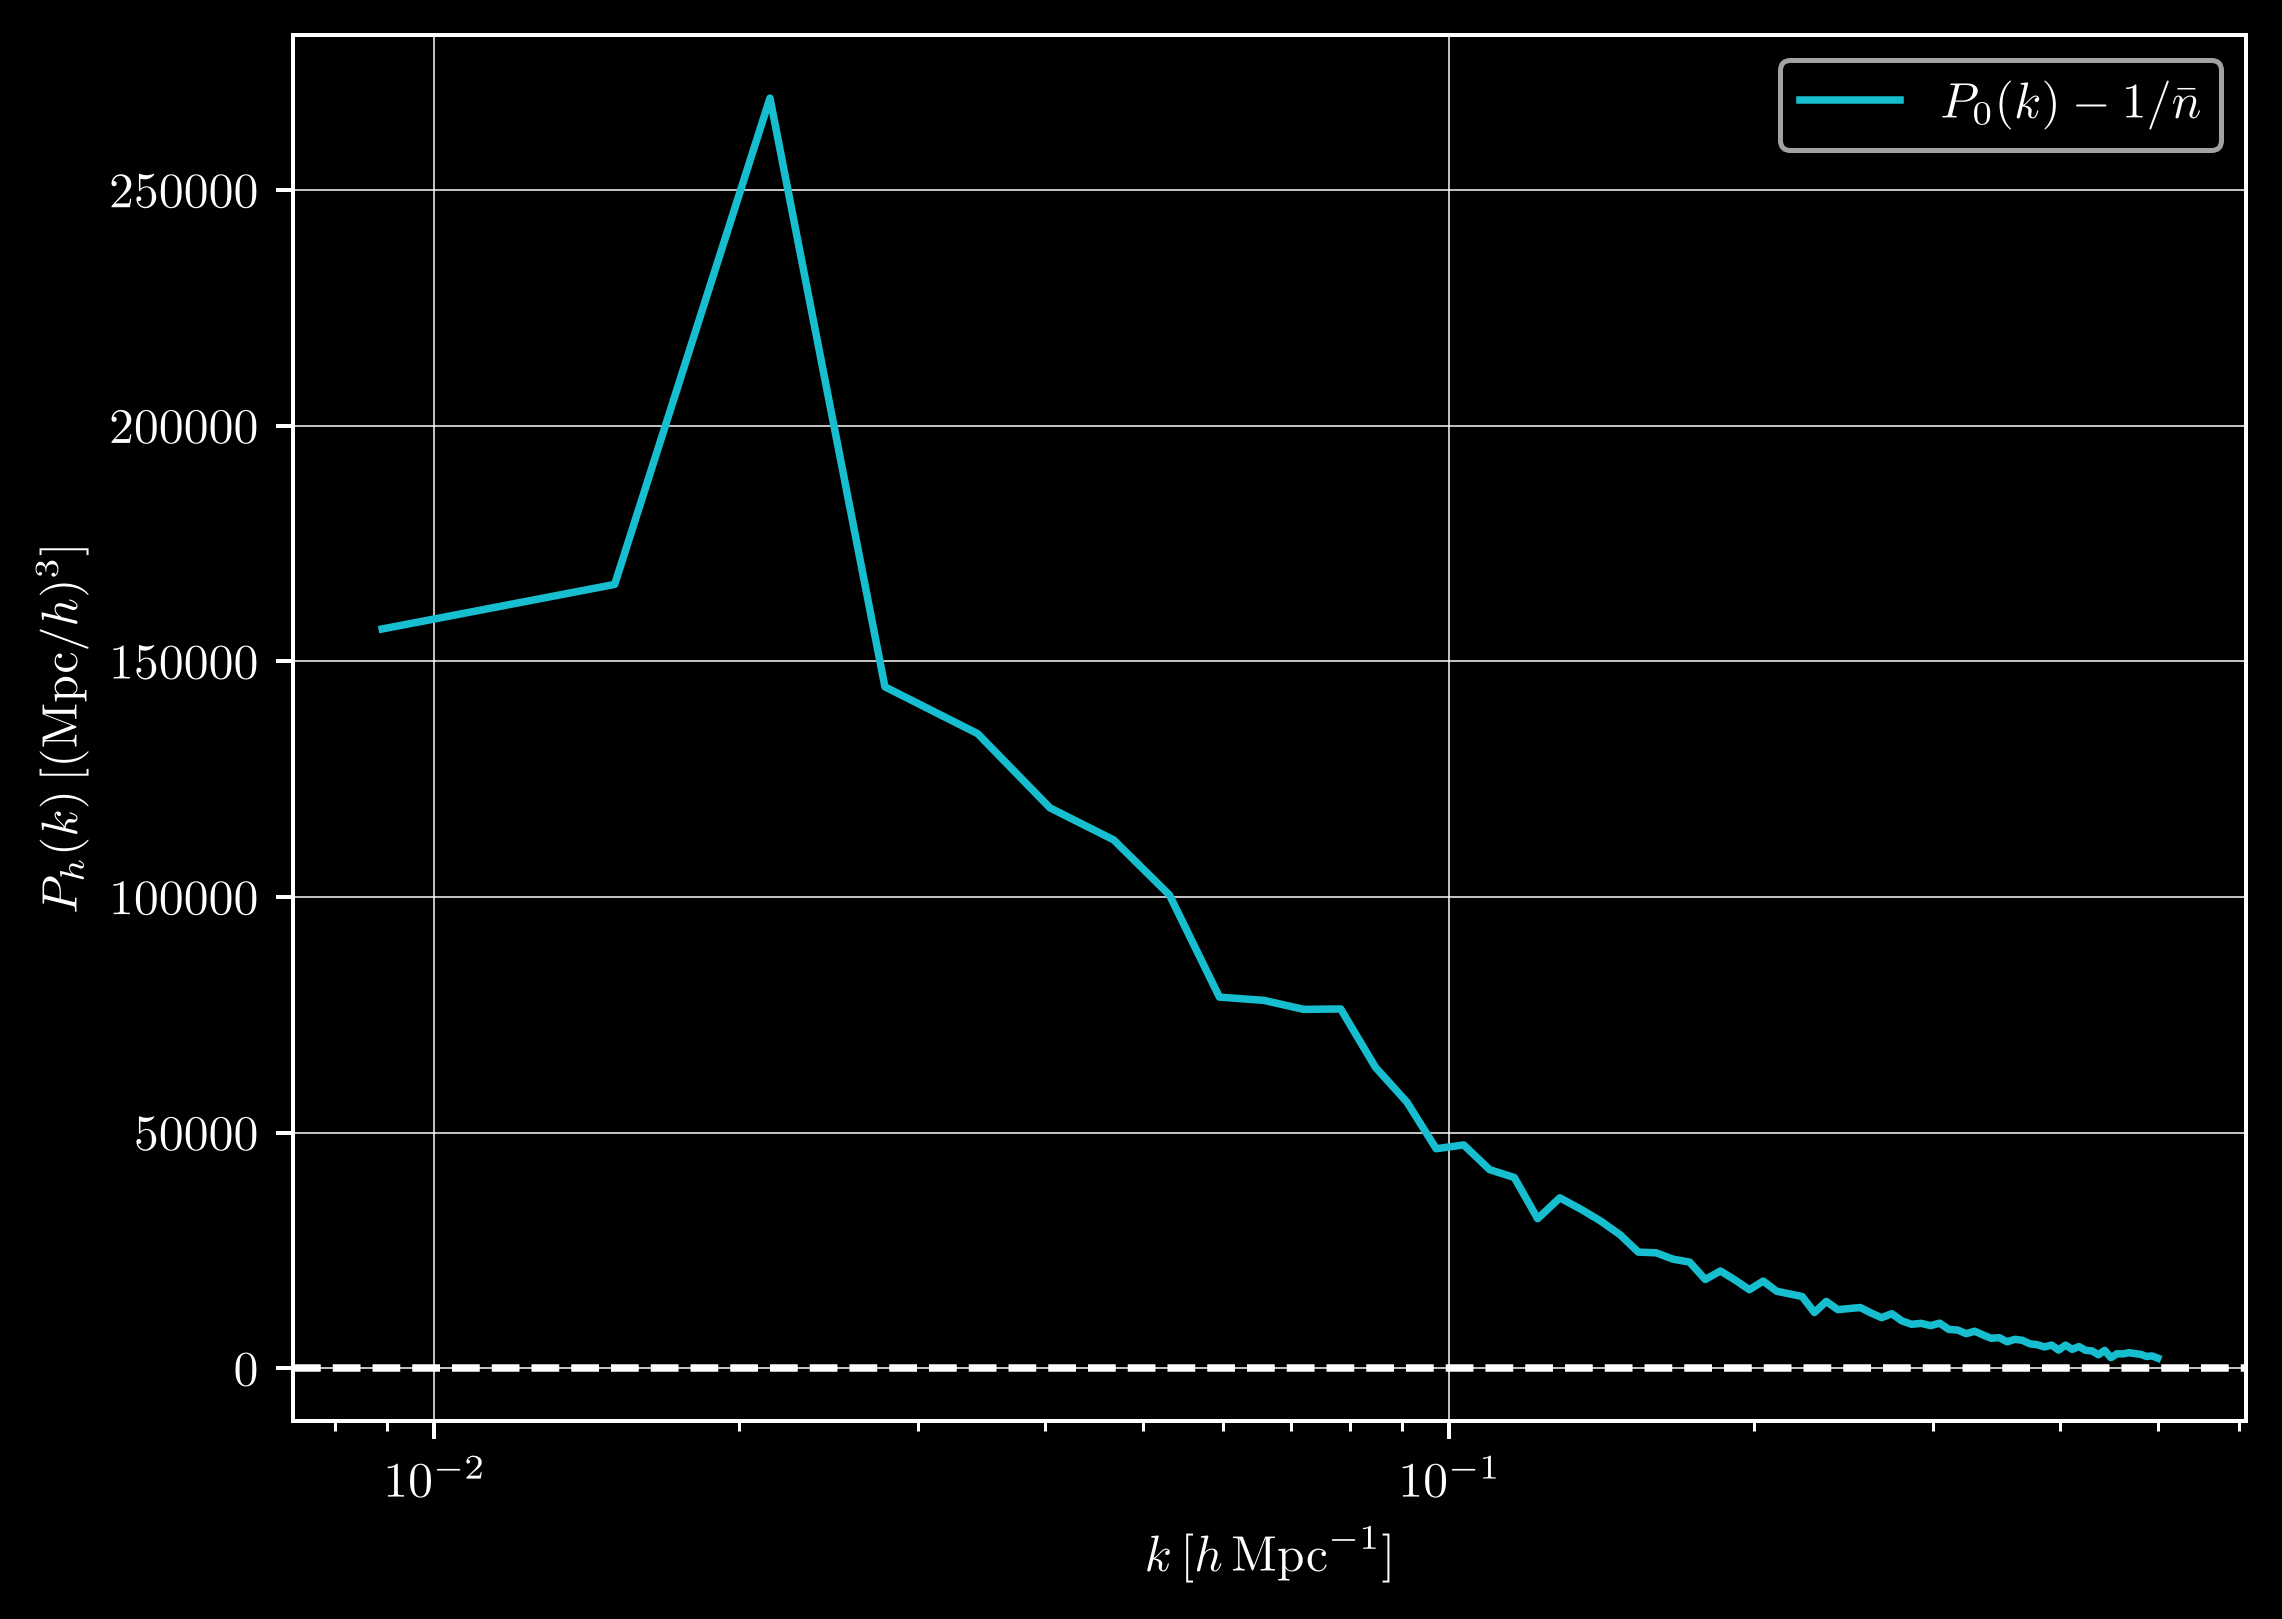

In [30]:
mask = (np.isfinite(k) & np.isfinite(Pk_clustering) & (Nmodes > 0)
        & (k >= 0.008) & (k <= 0.5))

fig, ax = plt.subplots(figsize=(7, 5))
plt.grid(lw=0.3)

ax.semilogx(k[mask], Pk_clustering[mask], label=r'$P_0(k)-1/\bar n$', c='#17becf')

ax.axhline(0.0, linestyle='--')

ax.set_xlabel(r'$k\,[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_h(k)\,[(\mathrm{Mpc}/h)^3]$')

plt.legend()
plt.show()

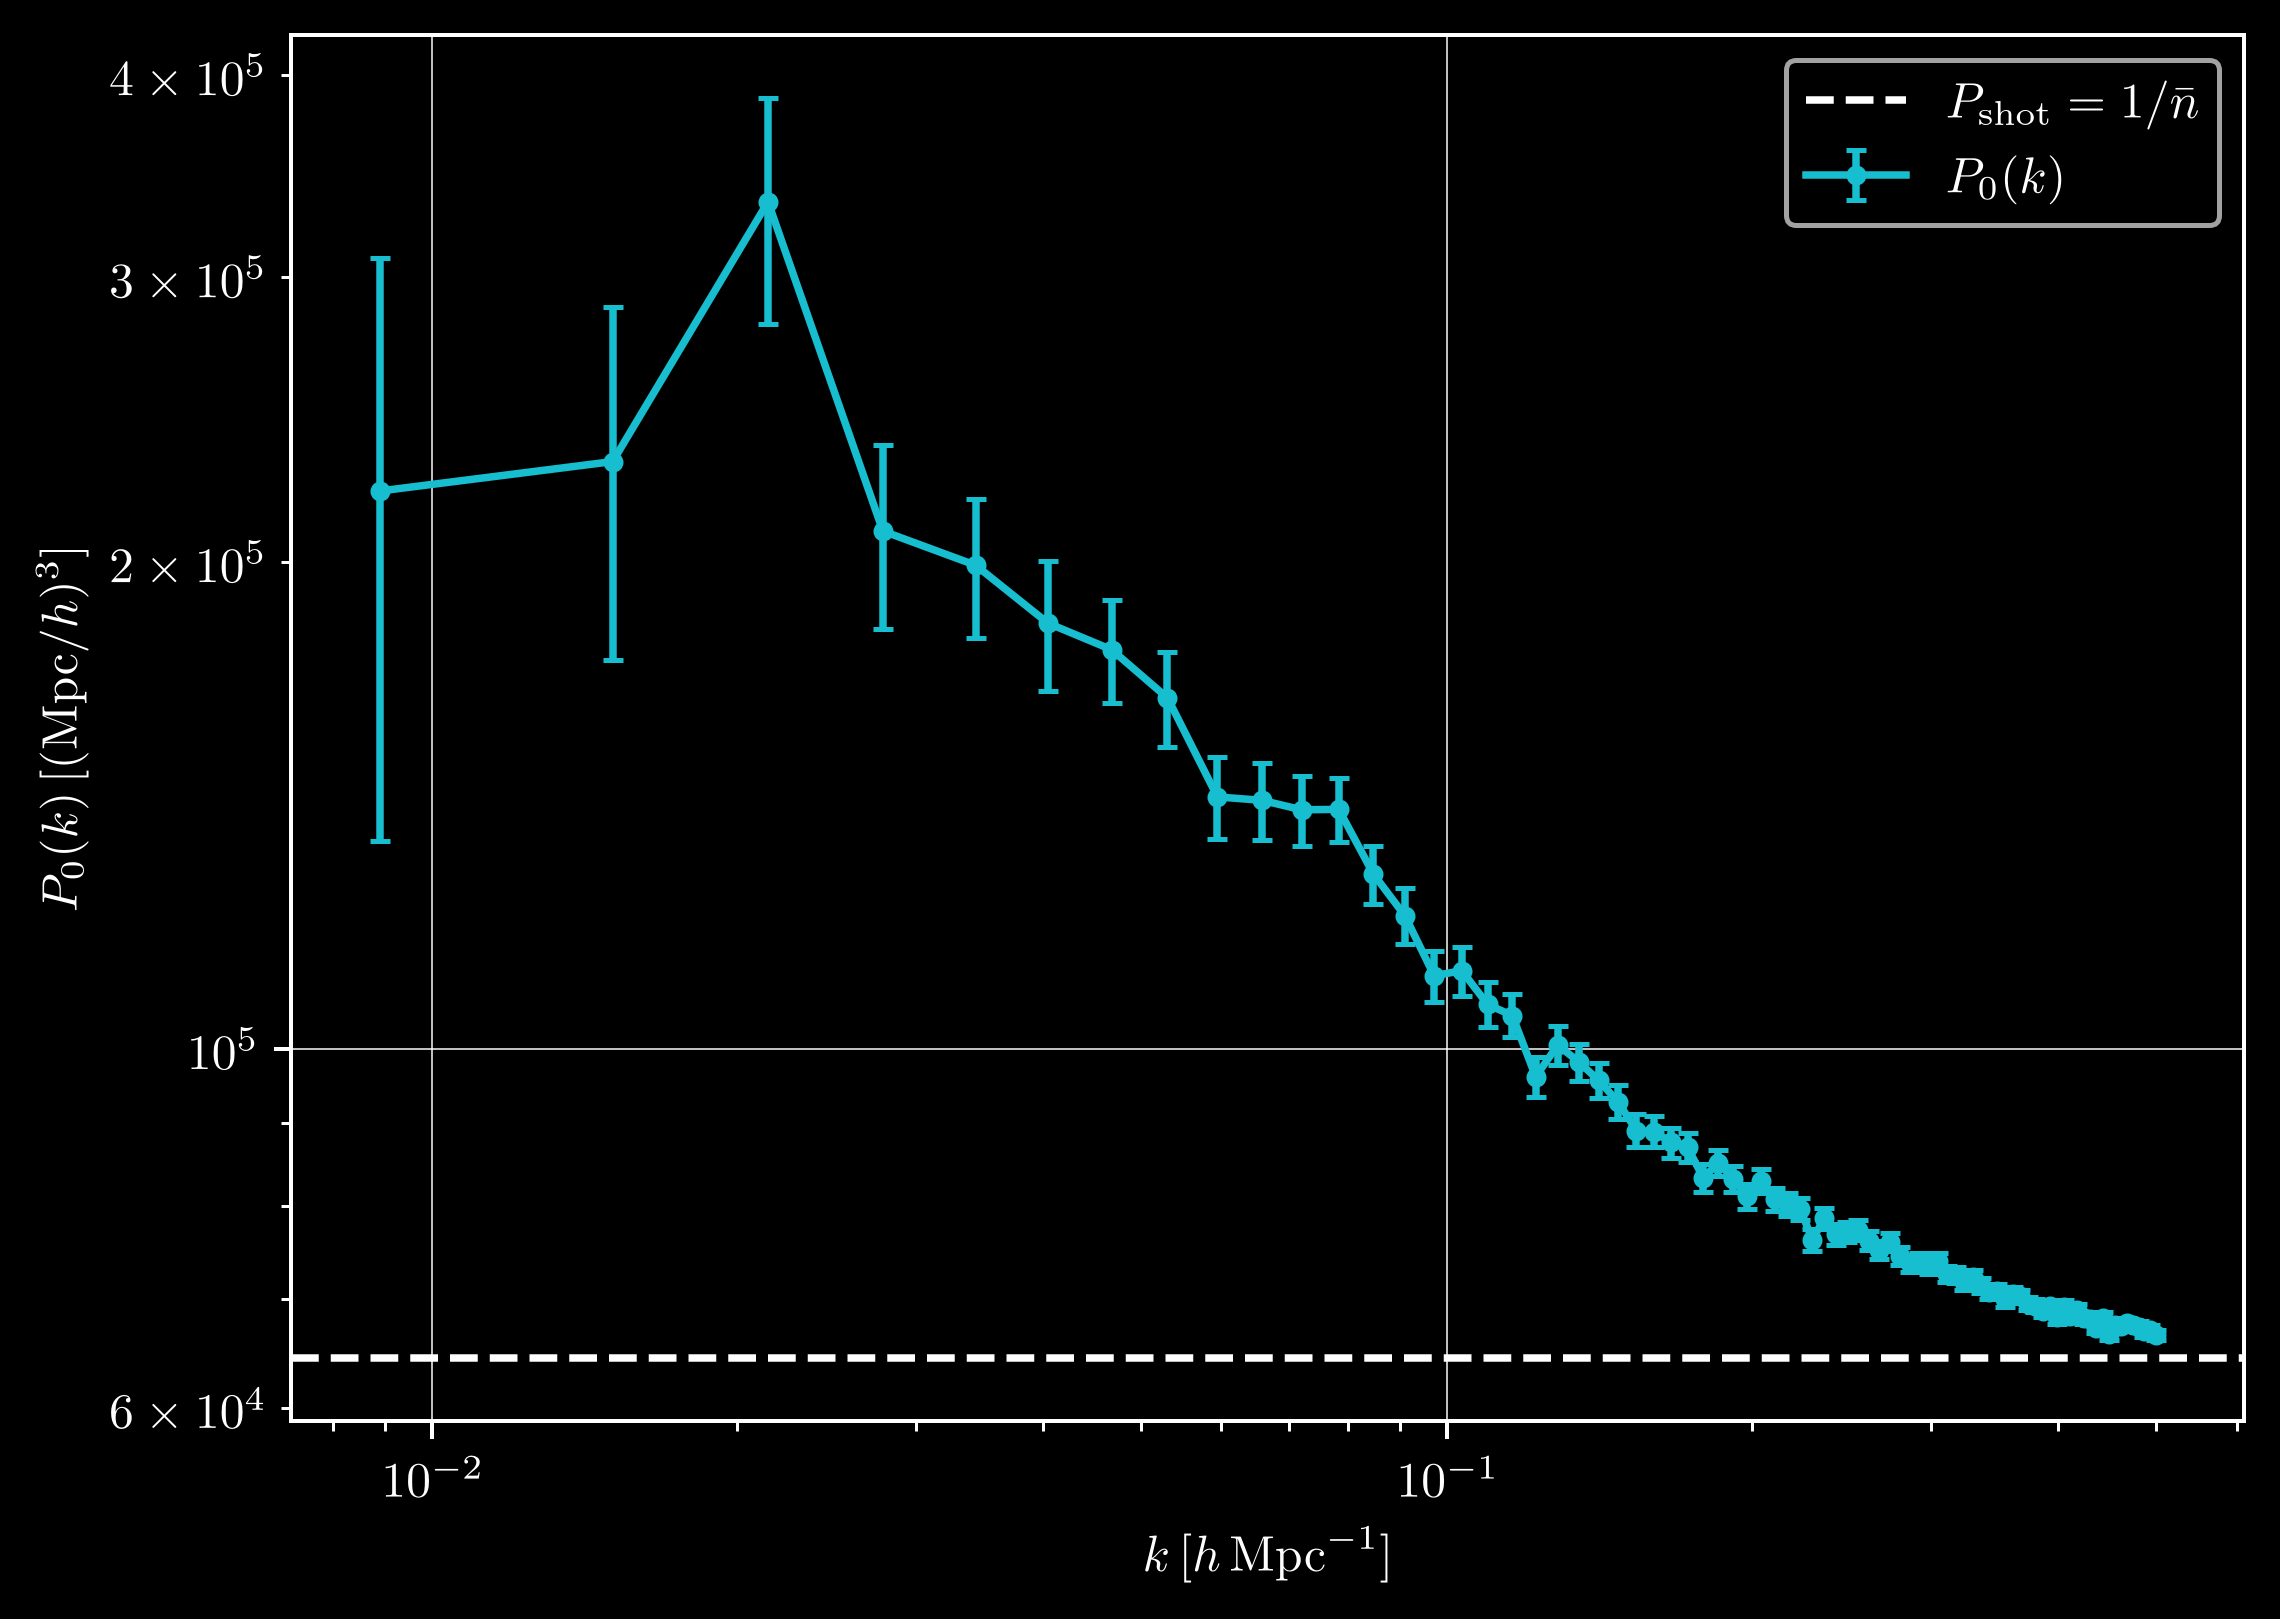

In [31]:
sigma_P = Pk0 * np.sqrt(2.0 / Nmodes)

mask = (np.isfinite(k) & np.isfinite(Pk0) & np.isfinite(sigma_P)
        & (Nmodes > 0) & (k >= 0.008) & (k <= 0.5))

fig, ax = plt.subplots(figsize=(7, 5))
plt.grid(lw=0.3)

ax.errorbar(k[mask], Pk0[mask], yerr=sigma_P[mask], fmt='.-',
            capsize=2, label=r'$P_0(k)$', c='#17becf')

ax.axhline(Pshot, linestyle='--', label=r'$P_{\rm shot}=1/\bar n$')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'$k\,[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_0(k)\,[(\mathrm{Mpc}/h)^3]$')
plt.legend()

plt.show()

### Marked

In [3]:
prob = Table.read(f'{base}/astra/probabilities/sim000/00/zone_00_sim000_snap003_probability_iterdata.fits.gz', hdu=1)
prob

TARGETID,TRACERTYPE,PVOID,PSHEET,PFILAMENT,PKNOT
int64,bytes24,float32,float32,float32,float32
1,HALO,0.0,0.4888889,0.51111114,0.0
2,HALO,0.0,0.6888889,0.31111112,0.0
3,HALO,0.4,0.6,0.0,0.0
4,HALO,0.0,0.26666668,0.62222224,0.11111111
5,HALO,0.044444446,0.7777778,0.17777778,0.0
6,HALO,0.15555556,0.73333335,0.11111111,0.0
7,HALO,0.0,0.5555556,0.4,0.044444446
8,HALO,0.13333334,0.8,0.06666667,0.0
9,HALO,0.08888889,0.8,0.11111111,0.0


In [ ]:
tab_final = join(tab_pos, tab_prob, keys='TARGETID', join_type='inner')
tab_final

In [ ]:
prob_cols = ['PVOID', 'PSHEET', 'PFILAMENT', 'PKNOT']
class_names = np.array(['Void', 'Sheet', 'Filament', 'Knot'])

In [ ]:
prob_matrix = np.column_stack([np.asarray(tab_final[col], dtype=float)
                               for col in prob_cols])

max_idx = np.argmax(prob_matrix, axis=1)

In [ ]:
tab_final['environment_class'] = class_names[max_idx]
tab_final['environment_probability'] = prob_matrix[np.arange(len(tab_final)),
                                                   max_idx]